In [ ]:
# 1) make sure to clear your dataset cache
# 2) run the script below to count tokens
# (opt) if you run this multiple times, you should clear the existing output json files first
# !bash .scripts/count_tokens.sh

In [2]:
!bash .scripts/count_tokens.sh

rdf4j_server
neo4j_server
Traceback (most recent call last):
  File "/home/vejvar-martin-nj/git/uT5-ssc/seq2seq/count_tokens.py", line 14, in <module>
    from seq2seq.utils.args import ModelArguments
ModuleNotFoundError: No module named 'seq2seq'
Traceback (most recent call last):
  File "/home/vejvar-martin-nj/git/uT5-ssc/seq2seq/count_tokens.py", line 14, in <module>
    from seq2seq.utils.args import ModelArguments
ModuleNotFoundError: No module named 'seq2seq'
Traceback (most recent call last):
  File "/home/vejvar-martin-nj/git/uT5-ssc/seq2seq/count_tokens.py", line 14, in <module>
    from seq2seq.utils.args import ModelArguments
ModuleNotFoundError: No module named 'seq2seq'
Traceback (most recent call last):
  File "/home/vejvar-martin-nj/git/uT5-ssc/seq2seq/count_tokens.py", line 14, in <module>
    from seq2seq.utils.args import ModelArguments
ModuleNotFoundError: No module named 'seq2seq'
Traceback (most recent call last):
  File "/home/vejvar-martin-nj/git/uT5-ssc/seq2seq/

4384


/tmp/ipykernel_1124572/864868886.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats = df.groupby(["lang", "schema_label"]).apply(aggregate).reset_index()


,mean_tokens,mean_trunc_tokens,trunc_ratio
lang,,,
sparql,188.943057,18.377385,0.062178
sql,168.408913,13.212818,0.049334
cypher,335.205599,88.952855,0.175134


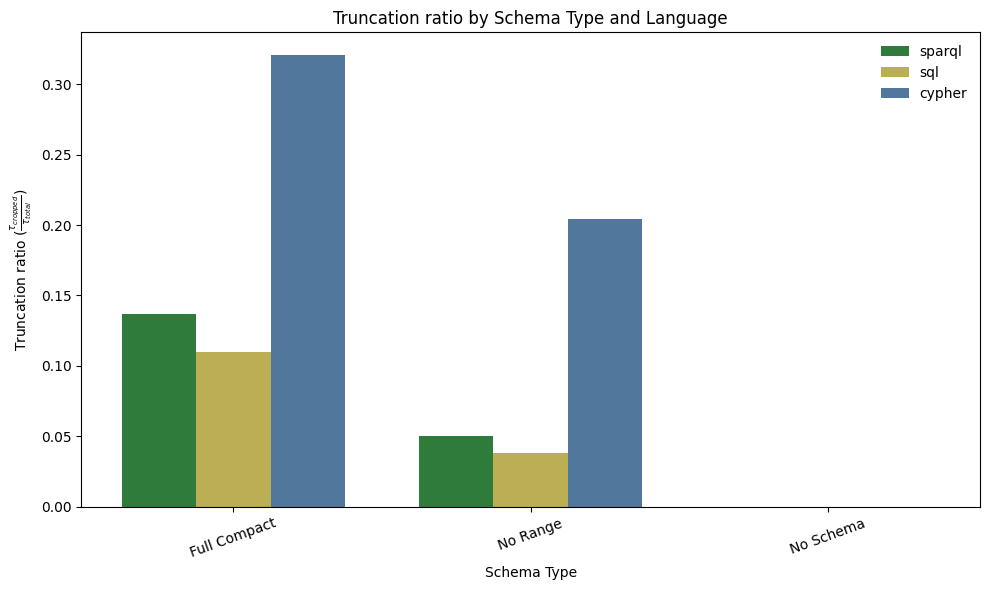

schema_label,Full Compact,No Range,No Schema
lang,,,
sparql,0.136593,0.049941,0.0
sql,0.109787,0.038213,0.0
cypher,0.320797,0.204606,0.0


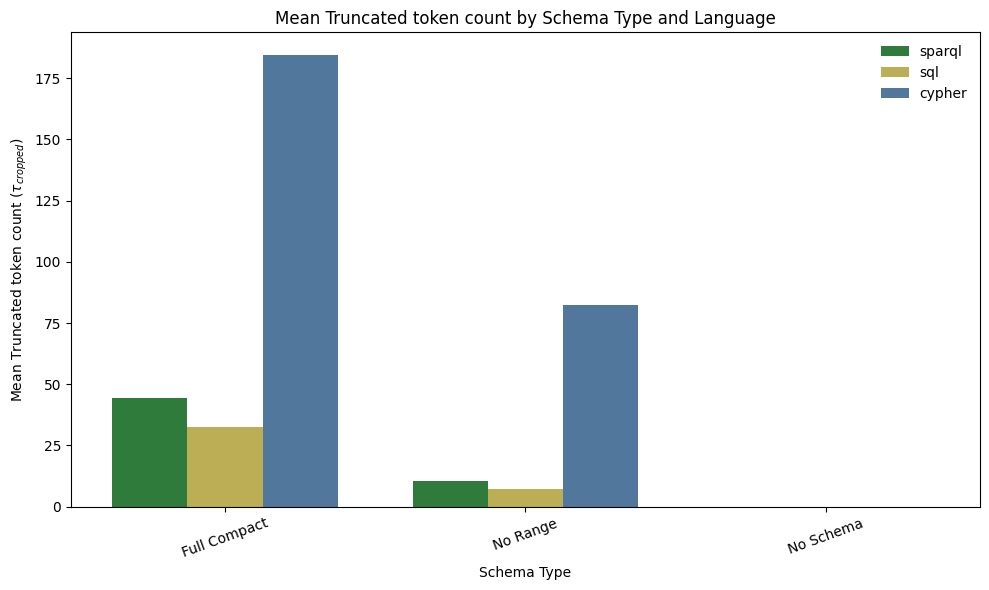

schema_label,Full Compact,No Range,No Schema
lang,,,
sparql,44.492155,10.640000,0.0
sql,32.408177,7.230276,0.0
cypher,184.549392,82.309171,0.0


In [3]:
# analysis.ipynb
import json
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------
# 1. Load all jsonl
# -----------------
base_dir = pathlib.Path("results/counts/")
records = []
for l_dir in base_dir.iterdir():
    if not l_dir.is_dir():
        continue
    lang = l_dir.name.lower()
    for schema_dir in l_dir.iterdir():
        if not schema_dir.is_dir():
            continue
        schema_type = schema_dir.name
        for file in schema_dir.glob("*.jsonl"):
            with file.open("r", encoding="utf-8") as f:
                for line in f:
                    rec = json.loads(line)
                    rec["lang"] = lang
                    rec["schema"] = schema_type
                    records.append(rec)

df = pd.DataFrame(records)
print(len(df[df["truncated_tokens"] > 0]))

# -----------------
# 2. Rename schema types for readability
# -----------------
schema_labels = {
    "compact": "Full Compact",
    "norange": "No Range",
    "peteshaw": "No Range",
    "none": "No Schema"
}
df["schema_label"] = df["schema"].map(schema_labels).fillna(df["schema"])

# -----------------
# 3. Aggregate stats
# -----------------
def aggregate(group):
    total_tokens = group["token_count"].sum()
    total_trunc_tokens = group["truncated_tokens"].sum()
    return pd.Series({
        "mean_tokens": total_tokens / len(group),
        "mean_trunc_tokens": total_trunc_tokens / len(group),
        "trunc_ratio": total_trunc_tokens / total_tokens if total_tokens > 0 else 0,
    })

stats = df.groupby(["lang", "schema_label"]).apply(aggregate).reset_index()

# -----------------
# 4. Language summary table
# -----------------
lang_table = stats.groupby("lang").agg({
    "mean_tokens": "mean",
    "mean_trunc_tokens": "mean",
    "trunc_ratio": "mean"  # mean across schema types
})
lang_table = lang_table.loc[["sparql", "sql", "cypher"]]  # enforce ordering
display(lang_table)

# -----------------
# 5. Pivot for trunc ratio (schema rows, lang cols)
# -----------------
pivot_trunc = stats.pivot(index="schema_label", columns="lang", values="trunc_ratio")

languages = ["sparql", "sql", "cypher"]
colors = {
    "sparql": "#2F7B3B",
    "sql": "#BCAE55",
    "cypher": "#51779C",
}

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.25
index = np.arange(len(pivot_trunc.index))

for i, lang in enumerate(languages):
    ax.bar(index + i*bar_width,
           pivot_trunc[lang].values,
           bar_width,
           label=lang,
           color=colors[lang])

ax.set_xlabel("Schema Type")
ax.set_ylabel(r"Truncation ratio ($\frac{\tau_{cropped}}{\tau_{total}}$)")
ax.set_title("Truncation ratio by Schema Type and Language")
ax.set_xticks(index + bar_width)
ax.set_xticklabels(pivot_trunc.index, rotation=20)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(base_dir.joinpath("trunc_ratios.png"), dpi=300)
plt.savefig(base_dir.joinpath("trunc_ratios.svg"))
plt.savefig(base_dir.joinpath("trunc_ratios.pdf"))
plt.show()

pivot_trunc = pivot_trunc.loc[:, languages]  # enforce column order
pivot_trunc = pivot_trunc.T  # languages as rows
pivot_trunc = pivot_trunc.loc[["sparql", "sql", "cypher"]]  # enforce row order
display(pivot_trunc)

# -----------------
# 6. Pivot for mean trunc token length (schema rows, lang cols)
# -----------------
pivot_mean_token_trunc = stats.pivot(index="schema_label", columns="lang", values="mean_trunc_tokens")

languages = ["sparql", "sql", "cypher"]
colors = {
    "sparql": "#2F7B3B",
    "sql": "#BCAE55",
    "cypher": "#51779C",
}

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.25
index = np.arange(len(pivot_mean_token_trunc.index))

for i, lang in enumerate(languages):
    ax.bar(index + i*bar_width,
           pivot_mean_token_trunc[lang].values,
           bar_width,
           label=lang,
           color=colors[lang])

ax.set_xlabel("Schema Type")
ax.set_ylabel(r"Mean Truncated token count ($\tau_{cropped}$)")
ax.set_title("Mean Truncated token count by Schema Type and Language")
ax.set_xticks(index + bar_width)
ax.set_xticklabels(pivot_mean_token_trunc.index, rotation=20)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(base_dir.joinpath("trunc_token_counts.png"), dpi=300)
plt.savefig(base_dir.joinpath("trunc_token_counts.svg"))
plt.savefig(base_dir.joinpath("trunc_token_counts.pdf"))
plt.show()

pivot_mean_token_trunc = pivot_mean_token_trunc.loc[:, languages]  # enforce column order
pivot_mean_token_trunc = pivot_mean_token_trunc.T  # languages as rows
pivot_mean_token_trunc = pivot_mean_token_trunc.loc[["sparql", "sql", "cypher"]]  # enforce row order
display(pivot_mean_token_trunc)


In [4]:
# -----------------
# 7. Token length and truncation distribution
# -----------------

# Compute per-sample truncation ratio
df["trunc_ratio_sample"] = df["truncated_tokens"] / df["token_count"]
# print(df[df["truncated_tokens"] > 0]["trunc_ratio_sample"])
# print(len(df[df["truncated_tokens"] > 0]))
# print(len(df))

# Drop NaNs that may result from 0 token_count
df = df.dropna(subset=["trunc_ratio_sample"])

print(len(df))


40725


,lang,schema_label,mean_token_len,std_token_len,var_token_len,mean_trunc_ratio,std_trunc_ratio,var_trunc_ratio
0,cypher,Full Compact,575.284199,510.879442,260997.803829,0.145227,0.230349,0.053061
1,cypher,No Range,402.281105,354.220943,125472.476223,0.077098,0.161724,0.026155
2,cypher,No Schema,28.051492,6.034329,36.413131,0.000000,0.000000,0.000000
3,sparql,Full Compact,325.727956,282.096558,79578.468195,0.043880,0.121196,0.014688
4,sparql,No Range,213.049724,176.809525,31261.608270,0.009209,0.065728,0.004320
5,sparql,No Schema,28.051492,6.034329,36.413131,0.000000,0.000000,0.000000
6,sql,Full Compact,295.191160,255.676939,65370.697092,0.031752,0.106007,0.011237
7,sql,No Range,189.207735,155.826918,24282.028455,0.006290,0.053088,0.002818
8,sql,No Schema,20.827845,5.506505,30.321594,0.000000,0.000000,0.000000


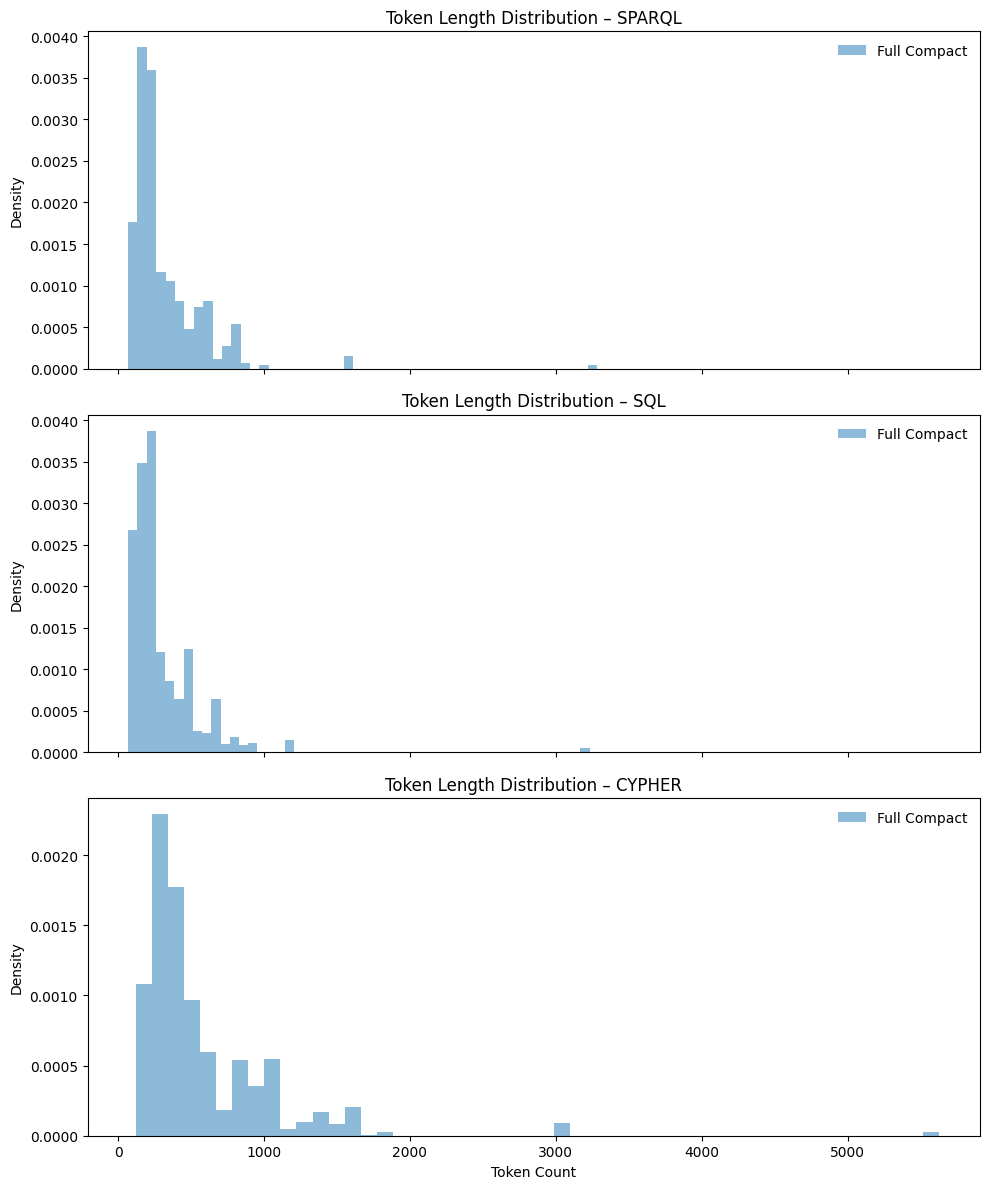

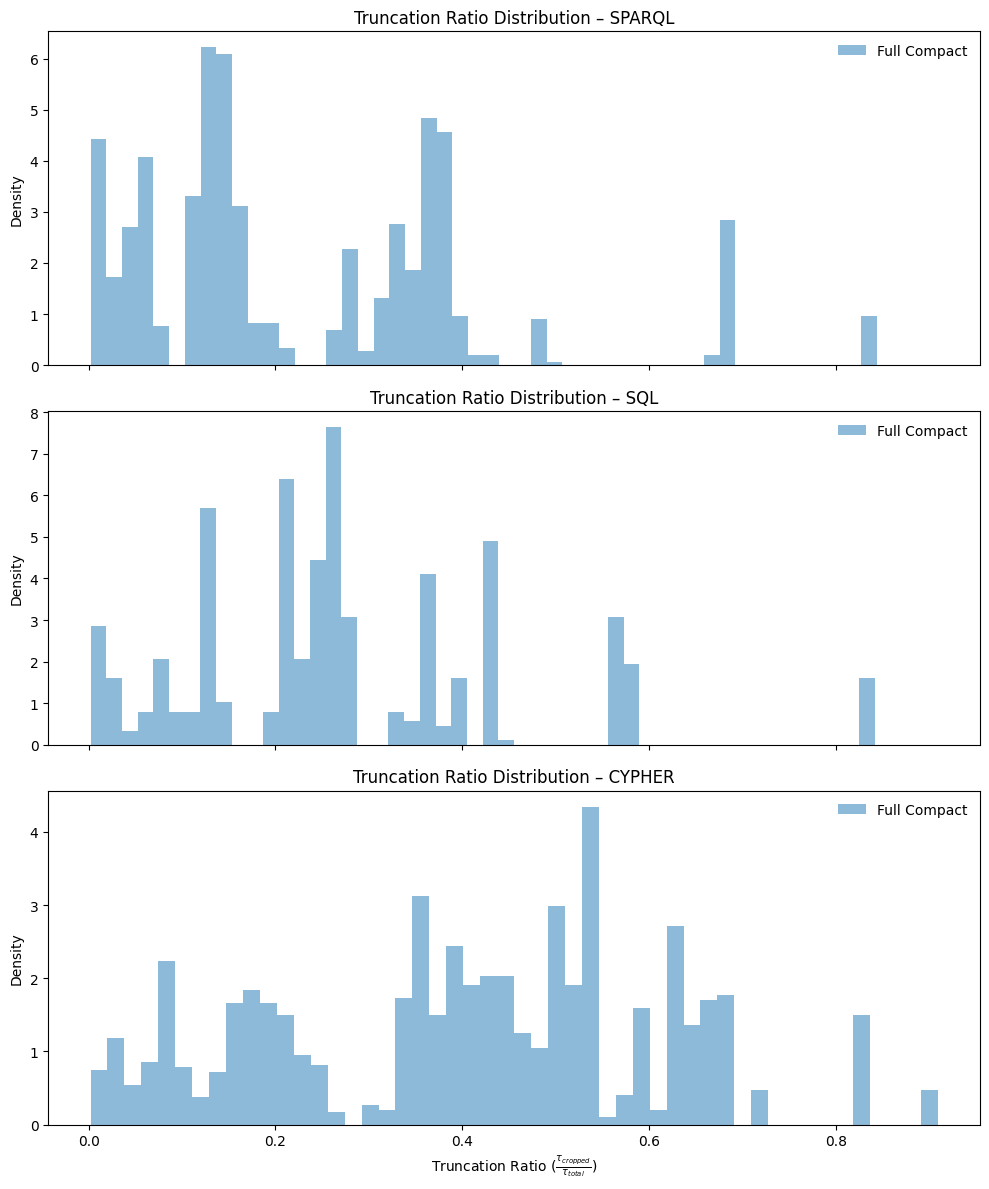

,lang,schema_label,Q1,Q3,IQR,Lower_Whisker,Upper_Whisker,Outlier_Count,Outlier_Percentage,Sample_Size
0,cypher,Full Compact,280.0,768.0,488.0,-452.0,1500.0,174,3.845304,4525
1,cypher,No Range,197.0,506.0,309.0,-266.5,969.5,222,4.906077,4525
2,cypher,No Schema,24.0,32.0,8.0,12.0,44.0,48,1.060773,4525
3,sparql,Full Compact,164.0,425.0,261.0,-227.5,816.5,150,3.314917,4525
4,sparql,No Range,108.0,280.0,172.0,-150.0,538.0,138,3.049724,4525
5,sparql,No Schema,24.0,32.0,8.0,12.0,44.0,48,1.060773,4525
6,sql,Full Compact,151.0,379.0,228.0,-191.0,721.0,168,3.712707,4525
7,sql,No Range,98.0,256.0,158.0,-139.0,493.0,128,2.828729,4525
8,sql,No Schema,17.0,24.0,7.0,6.5,34.5,87,1.922652,4525


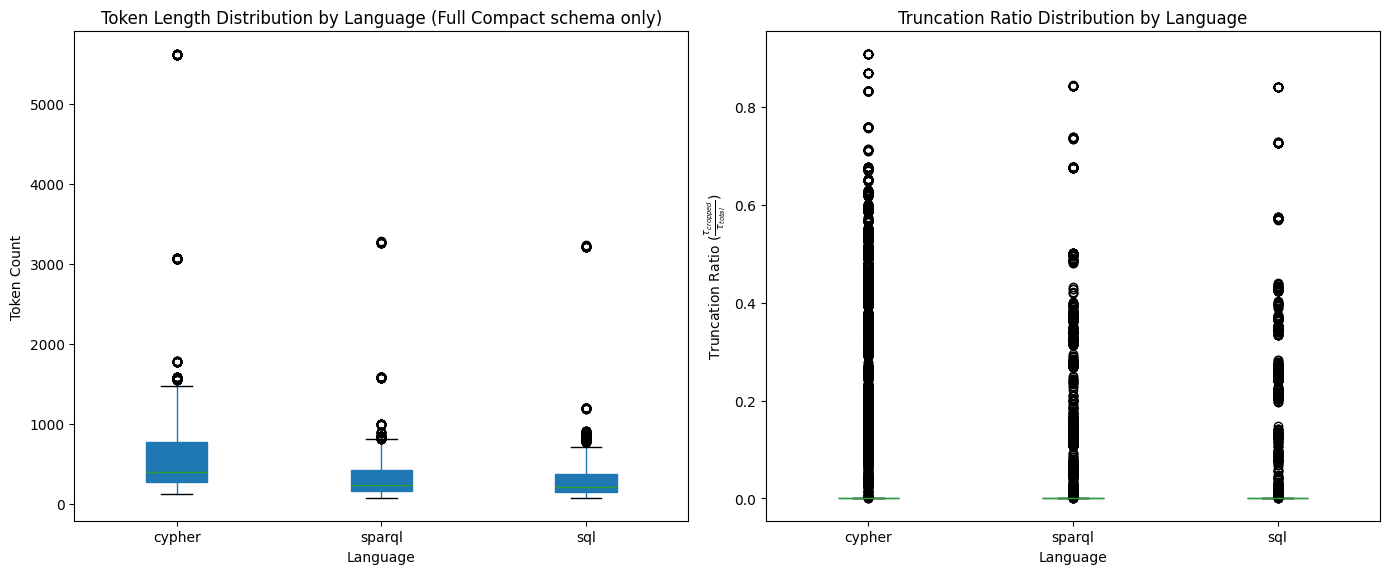

In [10]:
schemas = ["Full Compact"]  # df["schema_label"].unique()

# -----------------
# 7.1 Compute summary stats (mean, std, variance)
# -----------------
summary_stats = (
    df.groupby(["lang", "schema_label"])
    .agg(
        mean_token_len=("token_count", "mean"),
        std_token_len=("token_count", "std"),
        var_token_len=("token_count", "var"),
        mean_trunc_ratio=("trunc_ratio_sample", "mean"),
        std_trunc_ratio=("trunc_ratio_sample", "std"),
        var_trunc_ratio=("trunc_ratio_sample", "var"),
    )
    .reset_index()
)

display(summary_stats)

# Save stats
summary_stats.to_csv(base_dir.joinpath("token_trunc_distribution_stats.csv"), index=False)

# -----------------
# 7.2 Plot distribution of token lengths
# -----------------
fig, axes = plt.subplots(len(languages), 1, figsize=(10, 12), sharex=True)
for i, lang in enumerate(languages):
    subset = df[df["lang"] == lang]
    for schema in schemas:
        s = subset[subset["schema_label"] == schema]
        axes[i].hist(
            s["token_count"],
            bins=50,
            alpha=0.5,
            label=schema,
            density=True,
        )
    axes[i].set_title(f"Token Length Distribution – {lang.upper()}")
    axes[i].set_ylabel("Density")
    axes[i].legend(frameon=False)
axes[-1].set_xlabel("Token Count")
plt.tight_layout()
plt.savefig(base_dir.joinpath("token_length_distribution.png"), dpi=300)
plt.show()

# -----------------
# 7.3 Plot distribution of truncation ratio
# -----------------
fig, axes = plt.subplots(len(languages), 1, figsize=(10, 12), sharex=True)
for i, lang in enumerate(languages):
    subset = df[df["lang"] == lang]
    subset = subset[subset["truncated_tokens"] > 0]
    for schema in schemas:
        s = subset[subset["schema_label"] == schema]
        axes[i].hist(
            s["trunc_ratio_sample"],
            bins=50,
            alpha=0.5,
            label=schema,
            density=True,
        )
    axes[i].set_title(f"Truncation Ratio Distribution – {lang.upper()}")
    axes[i].set_ylabel("Density")
    axes[i].legend(frameon=False)
axes[-1].set_xlabel(r"Truncation Ratio ($\frac{\tau_{cropped}}{\tau_{total}}$)")
plt.tight_layout()
plt.savefig(base_dir.joinpath("truncation_ratio_distribution.png"), dpi=300)
plt.show()

# -----------------
# 7.3.5 Compute boxplot stats (IQR, whiskers, outliers) per language & schema
# -----------------
boxplot_stats = []

for (lang, schema), subset in df.groupby(["lang", "schema_label"]):
    q1 = subset["token_count"].quantile(0.25)
    q3 = subset["token_count"].quantile(0.75)
    iqr = q3 - q1

    # Define whiskers based on 1.5*IQR rule
    lower_whisker = q1 - 1.5 * iqr
    upper_whisker = q3 + 1.5 * iqr

    # Outlier detection
    outliers = subset[
        (subset["token_count"] < lower_whisker) | (subset["token_count"] > upper_whisker)
    ]

    boxplot_stats.append({
        "lang": lang,
        "schema_label": schema,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Whisker": lower_whisker,
        "Upper_Whisker": upper_whisker,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": 100 * len(outliers) / len(subset),
        "Sample_Size": len(subset)
    })

boxplot_stats_df = pd.DataFrame(boxplot_stats)
display(boxplot_stats_df)

# Optional: save results
boxplot_stats_df.to_csv(base_dir.joinpath("boxplot_stats_by_schema.csv"), index=False)


# -----------------
# 7.4 Boxplots for variance visualization
# -----------------
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Token length boxplot
df[df["schema_label"] == "Full Compact"].boxplot(column="token_count", by="lang", ax=ax[0], grid=False, patch_artist=True)
# df.boxplot(column="token_count", by="lang", ax=ax[0], grid=False, patch_artist=True)
ax[0].set_title("Token Length Distribution by Language (Full Compact schema only)")
ax[0].set_xlabel("Language")
ax[0].set_ylabel("Token Count")

# Truncation ratio boxplot
df.boxplot(column="trunc_ratio_sample", by="lang", ax=ax[1], grid=False, patch_artist=True)
ax[1].set_title("Truncation Ratio Distribution by Language")
ax[1].set_xlabel("Language")
ax[1].set_ylabel(r"Truncation Ratio ($\frac{\tau_{cropped}}{\tau_{total}}$)")

plt.suptitle("")
plt.tight_layout()
plt.savefig(base_dir.joinpath("distribution_boxplots.png"), dpi=300)
plt.show()

In [6]:
# -----------------
# 7.3.5 Compute boxplot stats (IQR, whiskers, outliers)
# -----------------
boxplot_stats = []

for lang, subset in df.groupby("lang"):
    q1 = subset["token_count"].quantile(0.25)
    q3 = subset["token_count"].quantile(0.75)
    iqr = q3 - q1

    # Define whiskers based on 1.5*IQR rule
    lower_whisker = q1 - 1.5 * iqr
    upper_whisker = q3 + 1.5 * iqr

    # Outlier detection
    outliers = subset[
        (subset["token_count"] < lower_whisker) | (subset["token_count"] > upper_whisker)
    ]

    boxplot_stats.append({
        "lang": lang,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Whisker": lower_whisker,
        "Upper_Whisker": upper_whisker,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": 100 * len(outliers) / len(subset)
    })

boxplot_stats_df = pd.DataFrame(boxplot_stats)
display(boxplot_stats_df)

# Optional: save to CSV
boxplot_stats_df.to_csv(base_dir.joinpath("boxplot_stats.csv"), index=False)

,lang,Q1,Q3,IQR,Lower_Whisker,Upper_Whisker,Outlier_Count,Outlier_Percentage
0,cypher,32.0,428.0,396.0,-562.0,1022.0,734,5.406998
1,sparql,32.0,245.0,213.0,-287.5,564.5,750,5.524862
2,sql,24.0,223.0,199.0,-274.5,521.5,607,4.471455



### Truncation Count Distribution Summary (Outliers Removed) ###
Removed 627 outliers from 40725 samples total.


/tmp/ipykernel_384946/314864502.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: remove_outliers_iqr(g, "truncated_tokens"))


,lang,schema_label,mean_trunc_count,std_trunc_count,count
0,cypher,Full Compact,3.355279,15.734741,4177
1,cypher,No Range,0.000000,0.000000,4401
2,cypher,No Schema,0.000000,0.000000,4525
3,sparql,Full Compact,0.000000,0.000000,4467
4,sparql,No Range,0.000000,0.000000,4500
5,sparql,No Schema,0.000000,0.000000,4525
6,sql,Full Compact,0.000000,0.000000,4467
7,sql,No Range,0.000000,0.000000,4511
8,sql,No Schema,0.000000,0.000000,4525



### Mean Truncation Count (by Schema and Language, Outliers Removed) ###


lang,sparql,sql,cypher
schema_label,,,
Full Compact,0.0,0.0,3.355279
No Range,0.0,0.0,0.000000
No Schema,0.0,0.0,0.000000



### Std Dev of Truncation Count (by Schema and Language, Outliers Removed) ###


lang,sparql,sql,cypher
schema_label,,,
Full Compact,0.0,0.0,15.734741
No Range,0.0,0.0,0.000000
No Schema,0.0,0.0,0.000000


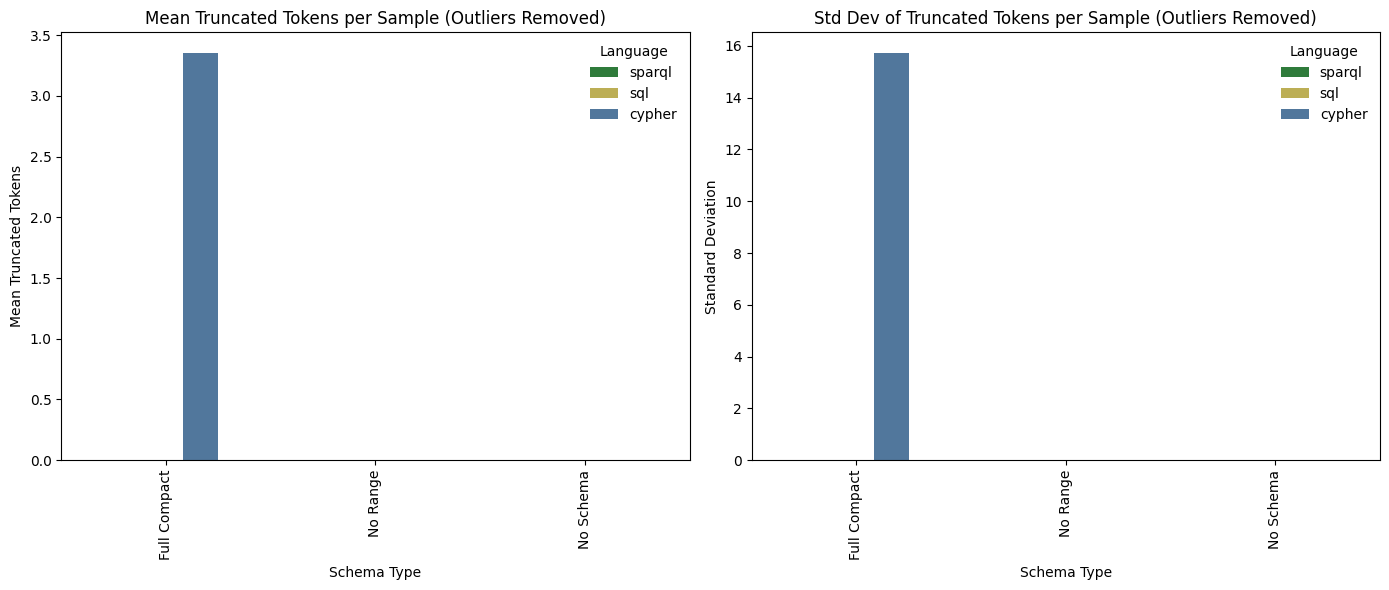

In [8]:
# -----------------
# 7.5 Truncation Count Distribution Analysis (with outlier removal)
# -----------------
print("\n### Truncation Count Distribution Summary (Outliers Removed) ###")

def remove_outliers_iqr(group, column):
    """Remove outliers from a DataFrame group using IQR."""
    Q1 = group[column].quantile(0.1)
    Q3 = group[column].quantile(0.9)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return group[(group[column] >= lower) & (group[column] <= upper)]

# Apply outlier removal per (lang, schema_label)
df_filtered = (
    df.groupby(["lang", "schema_label"], group_keys=False)
      .apply(lambda g: remove_outliers_iqr(g, "truncated_tokens"))
)

print(f"Removed {len(df) - len(df_filtered)} outliers from {len(df)} samples total.")

# Compute mean and std after outlier removal
trunc_stats = (
    df_filtered.groupby(["lang", "schema_label"])
    .agg(
        mean_trunc_count=("truncated_tokens", "mean"),
        std_trunc_count=("truncated_tokens", "std"),
        count=("truncated_tokens", "size")
    )
    .reset_index()
)

display(trunc_stats)

# Pivot tables for mean and std
pivot_mean_trunc = trunc_stats.pivot(index="schema_label", columns="lang", values="mean_trunc_count")
pivot_std_trunc = trunc_stats.pivot(index="schema_label", columns="lang", values="std_trunc_count")

# Enforce consistent order
pivot_mean_trunc = pivot_mean_trunc.loc[:, languages]
pivot_std_trunc = pivot_std_trunc.loc[:, languages]

print("\n### Mean Truncation Count (by Schema and Language, Outliers Removed) ###")
display(pivot_mean_trunc)

print("\n### Std Dev of Truncation Count (by Schema and Language, Outliers Removed) ###")
display(pivot_std_trunc)

# Save to CSV
pivot_mean_trunc.to_csv(base_dir.joinpath("trunc_count_mean_pivot_clean.csv"))
pivot_std_trunc.to_csv(base_dir.joinpath("trunc_count_std_pivot_clean.csv"))

# -----------------
# 7.6 Optional: Visualize mean and std of truncation counts
# -----------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mean bar plot
pivot_mean_trunc.plot.bar(ax=axes[0], color=[colors.get(lang, "#999999") for lang in pivot_mean_trunc.columns])
axes[0].set_title("Mean Truncated Tokens per Sample (Outliers Removed)")
axes[0].set_xlabel("Schema Type")
axes[0].set_ylabel("Mean Truncated Tokens")
axes[0].legend(title="Language", frameon=False)

# Std bar plot
pivot_std_trunc.plot.bar(ax=axes[1], color=[colors.get(lang, "#999999") for lang in pivot_std_trunc.columns])
axes[1].set_title("Std Dev of Truncated Tokens per Sample (Outliers Removed)")
axes[1].set_xlabel("Schema Type")
axes[1].set_ylabel("Standard Deviation")
axes[1].legend(title="Language", frameon=False)

plt.tight_layout()
plt.savefig(base_dir.joinpath("truncation_count_summary_clean.png"), dpi=300)
plt.show()

# Token count examples

In [ ]:
input_sql = "(sql) Count the number of stores the chain South has. | department_store | addresses : address_id (number) , address_details (text) | staff : staff_id (number) , staff_gender (text) , staff_name (text) | suppliers : supplier_id (number) , supplier_name (text) , supplier_phone (text) | department_store_chain : dept_store_chain_id (number) , dept_store_chain_name (text) | customers : customer_id (number) , payment_method_code (text) , customer_code (text) , customer_name (text) , customer_address (text) , customer_phone (text) , customer_email (text) | products : product_id (number) , product_type_code (text) , product_name (text) , product_price (number) | supplier_addresses : supplier_id (supplier_id) , address_id (address_id) , date_from (time) , date_to (time) | customer_addresses : customer_id (customer_id) , address_id (address_id) , date_from (time) , date_to (time) | customer_orders : order_id (number) , customer_id (customer_id) , order_status_code (text) , order_date (time) | department_stores : dept_store_id (number) , dept_store_chain_id (dept_store_chain_id) , store_name (text) , store_address (text) , store_phone (text) , store_email (text) | departments : department_id (number) , dept_store_id (dept_store_id) , department_name (text) | order_items : order_item_id (number) , order_id (order_id) , product_id (product_id) | product_suppliers : product_id (product_id) , supplier_id (supplier_id) , date_supplied_from (time) , date_supplied_to (time) , total_amount_purchased (text) , total_value_purchased (number) | staff_department_assignments : staff_id (staff_id) , department_id (department_id) , date_assigned_from (time) , job_title_code (text) , date_assigned_to (time)"
input_sparql = "(sparql) Count the number of stores the chain South has. | department_store | customer_orders: order_status_code (string) , order_id (integer) , order_date (dateTime) , customer_id (integer) , CUSTOMER_ID (customers) | department_store_chain: dept_store_chain_name (string) , dept_store_chain_id (integer) | departments: dept_store_id (integer) , department_name (string) , department_id (integer) , DEPT_STORE_ID (department_stores) | staff_department_assignments: staff_id (integer) , job_title_code (string) , department_id (integer) , date_assigned_to (dateTime) , date_assigned_from (dateTime) , STAFF_ID (staff) , DEPARTMENT_ID (departments) | supplier_addresses: supplier_id (integer) , date_to (dateTime) , date_from (dateTime) , address_id (integer) , SUPPLIER_ID (suppliers) , ADDRESS_ID (addresses) | suppliers: supplier_phone (string) , supplier_name (string) , supplier_id (integer) | department_stores: store_phone (string) , store_name (string) , store_email (string) , store_address (string) , dept_store_id (integer) , dept_store_chain_id (integer) , DEPT_STORE_CHAIN_ID (department_store_chain) | staff: staff_name (string) , staff_id (integer) , staff_gender (string) | customers: payment_method_code (string) , customer_phone (string) , customer_name (string) , customer_id (integer) , customer_email (string) , customer_code (string) , customer_address (string) | customer_addresses: date_to (dateTime) , date_from (dateTime) , customer_id (integer) , address_id (integer) , CUSTOMER_ID (customers) , ADDRESS_ID (addresses) | product_suppliers: total_value_purchased (decimal) , total_amount_purchased (string) , supplier_id (integer) , product_id (integer) , date_supplied_to (dateTime) , date_supplied_from (dateTime) , SUPPLIER_ID (suppliers) , PRODUCT_ID (products) | products: product_type_code (string) , product_price (decimal) , product_name (string) , product_id (integer) | order_items: product_id (integer) , order_item_id (integer) , order_id (integer) , PRODUCT_ID (products) , ORDER_ID (customer_orders) | addresses: address_id (integer) , address_details (string)"
input_cypher = "(cypher) Count the number of stores the chain South has. | department_store | ROOT__addresses: uri (String) , addresses__address_id (Long) , addresses__address_details (String) | ROOT__department_stores: uri (String) , department_stores__store_name (String) , department_stores__store_address (String) , department_stores__store_email (String) , department_stores__dept_store_id (Long) , department_stores__dept_store_chain_id (Long) , department_stores__store_phone (String) , department_stores__DEPT_STORE_CHAIN_ID (ROOT__department_store_chain) | ROOT__customers: uri (String) , customers__customer_address (String) , customers__payment_method_code (String) , customers__customer_email (String) , customers__customer_name (String) , customers__customer_code (String) , customers__customer_phone (String) , customers__customer_id (Long) | ROOT__suppliers: uri (String) , suppliers__supplier_id (Long) , suppliers__supplier_name (String) , suppliers__supplier_phone (String) | ROOT__departments: uri (String) , departments__dept_store_id (Long) , departments__department_id (Long) , departments__department_name (String) , departments__DEPT_STORE_ID (ROOT__department_stores) | ROOT__staff: uri (String) , staff__staff_gender (String) , staff__staff_id (Long) , staff__staff_name (String) | ROOT__order_items: uri (String) , order_items__product_id (Long) , order_items__order_id (Long) , order_items__order_item_id (Long) , order_items__ORDER_ID (ROOT__customer_orders) , order_items__PRODUCT_ID (ROOT__products) | ROOT__product_suppliers: uri (String) , product_suppliers__date_supplied_from (LocalDateTime) , product_suppliers__date_supplied_to (LocalDateTime) , product_suppliers__product_id (Long) , product_suppliers__total_value_purchased (Double) , product_suppliers__total_amount_purchased (String) , product_suppliers__supplier_id (Long) , product_suppliers__PRODUCT_ID (ROOT__products) , product_suppliers__SUPPLIER_ID (ROOT__suppliers) | ROOT__supplier_addresses: uri (String) , supplier_addresses__date_from (LocalDateTime) , supplier_addresses__address_id (Long) , supplier_addresses__date_to (LocalDateTime) , supplier_addresses__supplier_id (Long) , supplier_addresses__ADDRESS_ID (ROOT__addresses) , supplier_addresses__SUPPLIER_ID (ROOT__suppliers) | ROOT__customer_orders: uri (String) , customer_orders__order_status_code (String) , customer_orders__order_date (LocalDateTime) , customer_orders__customer_id (Long) , customer_orders__order_id (Long) , customer_orders__CUSTOMER_ID (ROOT__customers) | ROOT__department_store_chain: uri (String) , department_store_chain__dept_store_chain_name (String) , department_store_chain__dept_store_chain_id (Long) | ROOT__staff_department_assignments: uri (String) , staff_department_assignments__department_id (Long) , staff_department_assignments__job_title_code (String) , staff_department_assignments__date_assigned_from (LocalDateTime) , staff_department_assignments__date_assigned_to (LocalDateTime) , staff_department_assignments__staff_id (Long) , staff_department_assignments__DEPARTMENT_ID (ROOT__departments) , staff_department_assignments__STAFF_ID (ROOT__staff) | ROOT__products: uri (String) , products__product_id (Long) , products__product_name (String) , products__product_price (Double) , products__product_type_code (String) | ROOT__customer_addresses: uri (String) , customer_addresses__customer_id (Long) , customer_addresses__date_from (LocalDateTime) , customer_addresses__address_id (Long) , customer_addresses__date_to (LocalDateTime) , customer_addresses__ADDRESS_ID (ROOT__addresses) , customer_addresses__CUSTOMER_ID (ROOT__customers)"

In [8]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("/work/results/t5/ut5-ep19-openwebtext-clean/final_clean_grouped")
print(f"SQL: {len(tokenizer.tokenize(input_sql))}")
print(f"SPARQL: {len(tokenizer.tokenize(input_sparql))}")
print(f"Cypher: {len(tokenizer.tokenize(input_cypher))}")

SQL: 695
SPARQL: 816
Cypher: 461
